# Oscillating Droplet Analysis

Verification of the CSF surface tension implementation via an oscillating droplet.

**Setup:** Initially elliptical drop r(θ) = R₀(1 + ε·cos 2θ), R₀=0.2, ε=0.1.  
1×1 box, symmetry BCs, quasi-2D (single z-element). ρ=300, μ=0.1, σ=1.0 → La=12000, 40×40 SEM (p=7).

**Expected physics:** Surface tension drives the drop back to a circle; kinetic energy shows damped oscillation at the Lamb frequency for the n=2 mode.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation, PillowWriter
from mpi4py import MPI
import glob, os

from pysemtools.io.ppymech.neksuite import preadnek
from pysemtools.datatypes.msh import Mesh as msh_c
from pysemtools.datatypes.coef import Coef as coef_c
from pysemtools.datatypes.field import Field as field_c

comm = MPI.COMM_WORLD

# Physics parameters
mu    = 0.1
sigma = 1.0
rho   = 300.0
R0    = 0.2
D     = 2 * R0
La    = rho * sigma * D / mu**2
print(f'La = {La:.0f}')

# Results directory (relative to notebook location)
RESULTS_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'results')

# Discover field files
field_files = sorted(glob.glob(os.path.join(RESULTS_DIR, 'field0.f[0-9]*')))
N_SNAPSHOTS = len(field_files)
print(f'Found {N_SNAPSHOTS} field files in {RESULTS_DIR}')

La = 12000
Found 7 field files in /Volumes/sourcecode/fortran/neko-multiphase-spurious-currents/examples/oscillating_droplet/results


## Mesh and triangulation

Read coordinates from the initial field file, build an element-local quad→triangle
decomposition for smooth `tricontourf` rendering. Reused by all visualization cells.

In [2]:
xyz_info = preadnek(field_files[0], comm)
msh  = msh_c(comm, data=xyz_info)
coef = coef_c(msh, comm)

n_elem = msh.x.shape[0]
lx     = msh.x.shape[3]
ly     = msh.x.shape[2]

x_all, y_all, triangles = [], [], []
offset = 0
for e in range(n_elem):
    x_all.append(msh.x[e, 0, :, :].flatten())
    y_all.append(msh.y[e, 0, :, :].flatten())
    for j in range(ly - 1):
        for i in range(lx - 1):
            p0 = offset + j*lx + i
            p1 = offset + j*lx + (i+1)
            p2 = offset + (j+1)*lx + i
            p3 = offset + (j+1)*lx + (i+1)
            triangles.append([p0, p1, p3])
            triangles.append([p0, p3, p2])
    offset += lx * ly

x      = np.concatenate(x_all)
y      = np.concatenate(y_all)
triang = tri.Triangulation(x, y, np.array(triangles))
V      = float(np.sum(coef.B))
print(f'{n_elem} elements, {len(x)} points, {len(triangles)} triangles')

2026-03-03 15:59:57,631 - preadnek - INFO - Reading file: /Volumes/sourcecode/fortran/neko-multiphase-spurious-currents/examples/oscillating_droplet/results/field0.f00000


2026-03-03 15:59:57,829 - preadnek - INFO - Elapsed time: 0.19867900000000005s


2026-03-03 15:59:57,833 - Mesh - INFO - Initializing Mesh object from HexaData object.


2026-03-03 15:59:57,849 - Mesh - INFO - Initializing common attributes.


2026-03-03 15:59:57,851 - Mesh - INFO - Getting vertices


...

2026-03-03 15:59:58,173 - Coef - INFO - Calculating the mass matrix


2026-03-03 15:59:58,177 - Coef - INFO - Coef object initialized


2026-03-03 15:59:58,178 - Coef - INFO - Coef data is of type: float64


2026-03-03 15:59:58,178 - Coef - INFO - Elapsed time: 0.26212100000000005s


1600 elements, 102400 points, 156800 triangles


## Part A: Snapshots through the oscillation cycle

Phase field φ and velocity magnitude |u| at evenly-spaced times.  
**All panels share the same colorbar** — amplitude decay is directly visible as the
velocity panels get darker toward the right.

2026-03-03 15:59:58,702 - preadnek - INFO - Reading file: /Volumes/sourcecode/fortran/neko-multiphase-spurious-currents/examples/oscillating_droplet/results/field0.f00020


2026-03-03 15:59:58,852 - preadnek - INFO - Elapsed time: 0.14973400000000003s


2026-03-03 15:59:58,855 - Field - INFO - Initializing Field object from HexaData


2026-03-03 15:59:58,885 - Field - INFO - Field object initialized


2026-03-03 15:59:58,886 - Field - INFO - Elapsed time: 0.030394000000000254s


...

2026-03-03 15:59:59,730 - preadnek - INFO - Elapsed time: 0.11687599999999998s


2026-03-03 15:59:59,743 - Field - INFO - Initializing Field object from HexaData


2026-03-03 15:59:59,767 - Field - INFO - Field object initialized


2026-03-03 15:59:59,768 - Field - INFO - Elapsed time: 0.025017999999999763s


Global |u|_max across snapshots: 1.746e-02


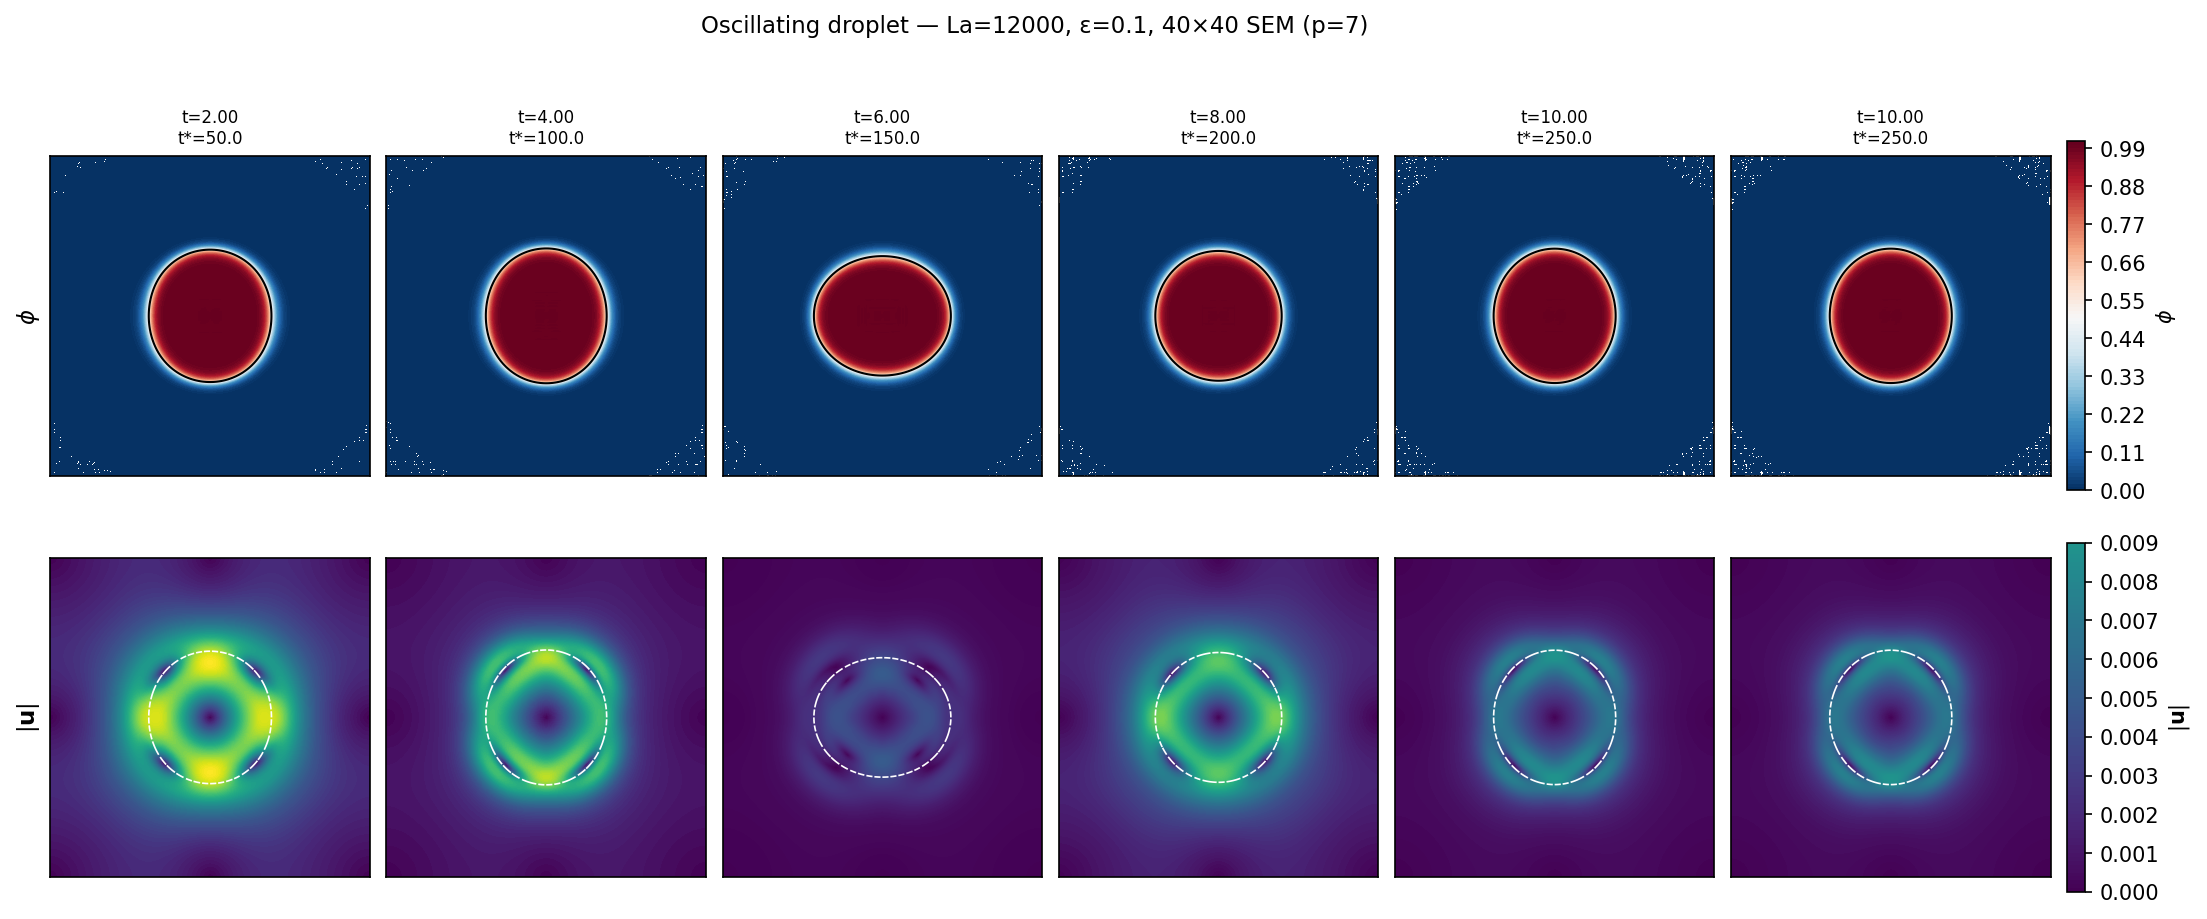

In [3]:
# Skip field_files[0] (t=0, zero velocity) — would set global vel scale to 0 and waste a panel
field_files_nonzero = field_files[1:]
if len(field_files_nonzero) >= 6:
    snap_indices = np.linspace(0, len(field_files_nonzero) - 1, 6, dtype=int)
else:
    snap_indices = np.arange(len(field_files_nonzero))
n_plots = len(snap_indices)

# Pre-load snapshots and compute global velocity scale
snap_data = []
for idx in snap_indices:
    data = preadnek(field_files_nonzero[idx], comm)
    fld  = field_c(comm, data=data)
    phi  = fld.fields['scal'][0][:, 0, :, :].flatten()
    u    = fld.fields['vel'][0][:, 0, :, :].flatten()
    v    = fld.fields['vel'][1][:, 0, :, :].flatten()
    snap_data.append({'t': fld.t,
                      't_star': sigma * fld.t / (mu * D),
                      'phi': phi,
                      'umag': np.sqrt(u**2 + v**2)})

vel_global_max = max(s['umag'].max() for s in snap_data)
print(f'Global |u|_max across snapshots: {vel_global_max:.3e}')

# Figure: n_plots data columns + 1 narrow colorbar column
fig = plt.figure(figsize=(2.8*n_plots + 0.7, 6.5), dpi=150)
gs  = gridspec.GridSpec(2, n_plots + 1,
                        width_ratios=[1]*n_plots + [0.055],
                        wspace=0.06, hspace=0.15)

cf_phi_last = None
cf_vel_last = None
for col, snap in enumerate(snap_data):
    ax = fig.add_subplot(gs[0, col])
    cf_phi_last = ax.tricontourf(triang, snap['phi'], levels=100,
                                  cmap='RdBu_r', vmin=0, vmax=1)
    ax.tricontour(triang, snap['phi'], levels=[0.5], colors='k', linewidths=1.0)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f't={snap["t"]:.2f}\nt*={snap["t_star"]:.1f}', fontsize=8)
    if col == 0: ax.set_ylabel(r'$\phi$', fontsize=11)

    ax = fig.add_subplot(gs[1, col])
    cf_vel_last = ax.tricontourf(triang, snap['umag'], levels=100,
                                  cmap='viridis', vmin=0, vmax=vel_global_max)
    ax.tricontour(triang, snap['phi'], levels=[0.5],
                  colors='w', linewidths=0.8, linestyles='--')
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    if col == 0: ax.set_ylabel(r'$|\mathbf{u}|$', fontsize=11)

# Shared colorbars
cb1 = fig.colorbar(cf_phi_last, cax=fig.add_subplot(gs[0, -1]))
cb1.set_label(r'$\phi$')
cb2 = fig.colorbar(cf_vel_last, cax=fig.add_subplot(gs[1, -1]))
cb2.set_label(r'$|\mathbf{u}|$')

fig.suptitle(f'Oscillating droplet — La={La:.0f}, ε=0.1, 40×40 SEM (p=7)',
             fontsize=11, y=1.01)
plt.savefig('oscillating_droplet_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

## Part B: Kinetic energy and droplet shape

Ekin(t*) and u_max show the damped oscillation driven by surface tension.  
The **aspect ratio** a/b (from φ second moments) tracks the actual shape deformation and
should oscillate at the Lamb n=2 frequency ω₂ = √(8σ / 5ρR₀³) with exponential decay.  
Dashed vertical lines mark multiples of the predicted Lamb period T*.

2026-03-03 16:00:10,867 - preadnek - INFO - Reading file: /Volumes/sourcecode/fortran/neko-multiphase-spurious-currents/examples/oscillating_droplet/results/field0.f00000


2026-03-03 16:00:11,019 - preadnek - INFO - Elapsed time: 0.1519200000000005s


2026-03-03 16:00:11,031 - Field - INFO - Initializing Field object from HexaData


2026-03-03 16:00:11,060 - Field - INFO - Field object initialized


2026-03-03 16:00:11,061 - Field - INFO - Elapsed time: 0.03035600000000116s


...

2026-03-03 16:00:12,095 - preadnek - INFO - Elapsed time: 0.10842300000000016s


2026-03-03 16:00:12,104 - Field - INFO - Initializing Field object from HexaData


2026-03-03 16:00:12,129 - Field - INFO - Field object initialized


2026-03-03 16:00:12,130 - Field - INFO - Elapsed time: 0.026018999999999792s


Lamb period: T = 7.695  →  T* = 192.4


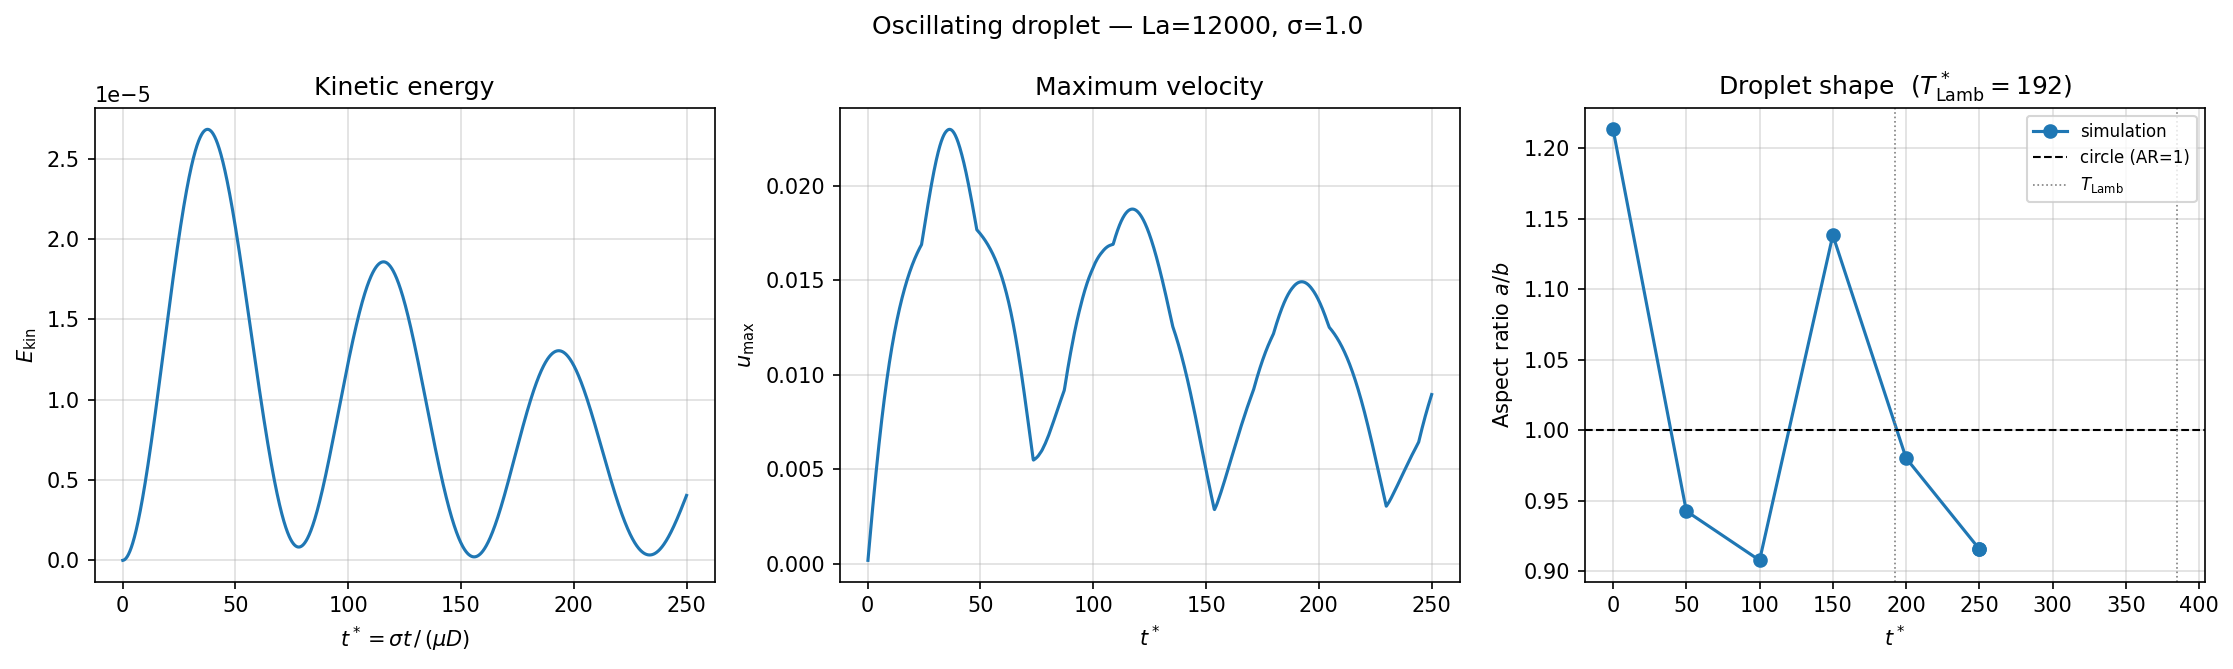

Peak Ekin:  2.6820e-05
Peak u_max: 2.3004e-02


In [4]:
# Load ekin.csv — skip t=0 (zero velocity initial condition distorts y-axis range)
ekin_csv  = np.genfromtxt(os.path.join(RESULTS_DIR, 'ekin.csv'), delimiter=',', comments='#')
ekin_csv  = ekin_csv[ekin_csv[:, 0] > 0]   # drop t=0 row
t_csv     = ekin_csv[:, 0]
Ekin_csv  = ekin_csv[:, 1]
u_max_csv = ekin_csv[:, 3]
t_star    = sigma * t_csv / (mu * D)

# Aspect ratio from field files — weighted second moments of φ
# For a uniform ellipse with semi-axes a (x) and b (y): <(x-xc)²>_φ = a²/4
# so a = 2√Ixx, b = 2√Iyy, AR = a/b = √(Ixx/Iyy)
B_flat = coef.B[:, 0, :, :].flatten()
times_ar, AR_vals = [], []
for fname in field_files:
    data = preadnek(fname, comm)
    fld  = field_c(comm, data=data)
    phi  = fld.fields['scal'][0][:, 0, :, :].flatten()
    w    = B_flat * np.clip(phi, 0, None)
    W    = w.sum()
    xc   = (w * x).sum() / W
    yc   = (w * y).sum() / W
    Ixx  = (w * (x - xc)**2).sum() / W
    Iyy  = (w * (y - yc)**2).sum() / W
    times_ar.append(fld.t)
    AR_vals.append(np.sqrt(Ixx / Iyy))

times_ar  = np.array(times_ar)
AR_vals   = np.array(AR_vals)
t_star_ar = sigma * times_ar / (mu * D)

# Lamb n=2 frequency for equal-density two-fluid drop: ω² = 8σ/(5ρR₀³)
omega_lamb  = np.sqrt(8 * sigma / (5 * rho * R0**3))
T_lamb      = 2 * np.pi / omega_lamb
t_star_lamb = T_lamb * sigma / (mu * D)
print(f'Lamb period: T = {T_lamb:.3f}  →  T* = {t_star_lamb:.1f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), dpi=150)

# Linear scale — shows the damped oscillation decaying toward zero
axes[0].plot(t_star, Ekin_csv, lw=1.5)
axes[0].set_xlabel(r'$t^* = \sigma t\,/\,(\mu D)$')
axes[0].set_ylabel(r'$E_{\rm kin}$')
axes[0].set_title('Kinetic energy')
axes[0].grid(True, alpha=0.4)

axes[1].plot(t_star, u_max_csv, lw=1.5)
axes[1].set_xlabel(r'$t^*$')
axes[1].set_ylabel(r'$u_{\max}$')
axes[1].set_title('Maximum velocity')
axes[1].grid(True, alpha=0.4)

axes[2].plot(t_star_ar, AR_vals, 'o-', lw=1.5, markersize=6, label='simulation')
axes[2].axhline(1.0, color='k', ls='--', lw=1, label='circle (AR=1)')
for k in range(1, int(t_star_ar[-1] / t_star_lamb) + 2):
    axes[2].axvline(k * t_star_lamb, color='gray', ls=':', lw=0.8,
                    label=r'$T_{\rm Lamb}$' if k == 1 else None)
axes[2].set_xlabel(r'$t^*$')
axes[2].set_ylabel(r'Aspect ratio $a/b$')
axes[2].set_title(f'Droplet shape  ($T^*_{{\\rm Lamb}} = {t_star_lamb:.0f}$)')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.4)

fig.suptitle(f'Oscillating droplet — La={La:.0f}, σ={sigma}')
plt.tight_layout()
plt.savefig('oscillating_droplet_ekin.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Peak Ekin:  {Ekin_csv.max():.4e}')
print(f'Peak u_max: {u_max_csv.max():.4e}')

## Part C: Ekin cross-check — field files vs CSV

2026-03-03 16:00:13,660 - preadnek - INFO - Reading file: /Volumes/sourcecode/fortran/neko-multiphase-spurious-currents/examples/oscillating_droplet/results/field0.f00000


2026-03-03 16:00:13,834 - preadnek - INFO - Elapsed time: 0.17361299999999957s


2026-03-03 16:00:13,845 - Field - INFO - Initializing Field object from HexaData


2026-03-03 16:00:13,876 - Field - INFO - Field object initialized


2026-03-03 16:00:13,877 - Field - INFO - Elapsed time: 0.03183100000000039s


...

2026-03-03 16:00:14,868 - preadnek - INFO - Reading file: /Volumes/sourcecode/fortran/neko-multiphase-spurious-currents/examples/oscillating_droplet/results/field0.f00101


2026-03-03 16:00:15,010 - preadnek - INFO - Elapsed time: 0.14194599999999724s


2026-03-03 16:00:15,027 - Field - INFO - Initializing Field object from HexaData


2026-03-03 16:00:15,059 - Field - INFO - Field object initialized


2026-03-03 16:00:15,060 - Field - INFO - Elapsed time: 0.03248999999999924s


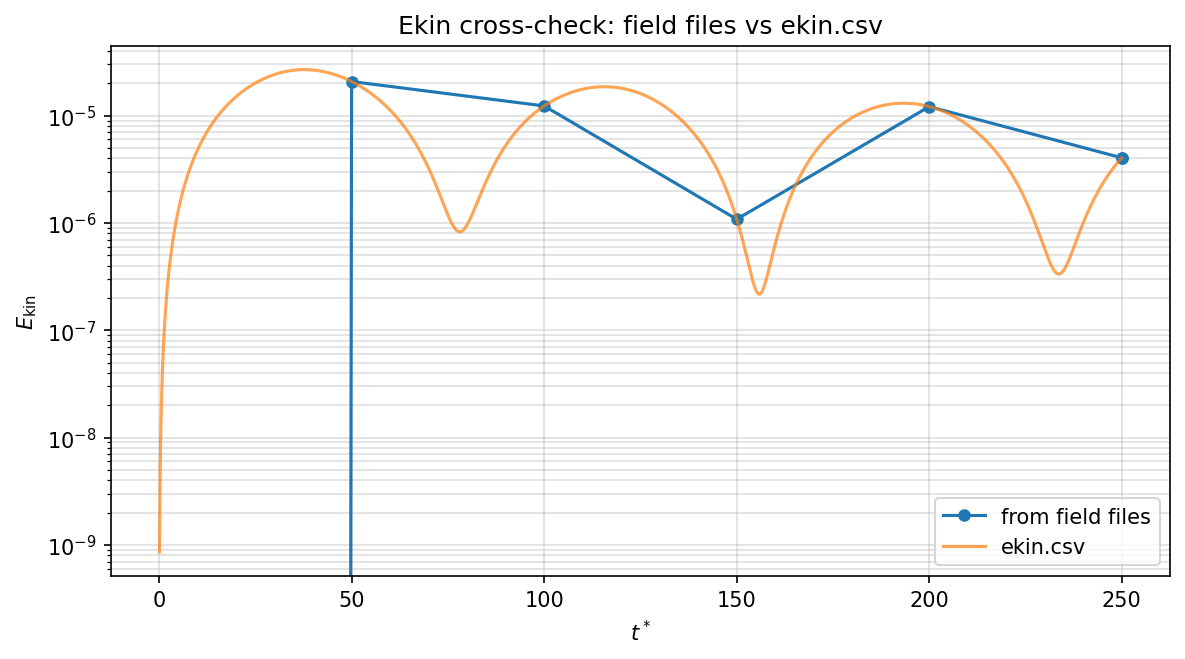

In [5]:
times_field = []
Ekin_fields = []

for fname in field_files:
    data   = preadnek(fname, comm)
    fld    = field_c(comm, data=data)
    u_snap = fld.fields['vel'][0]
    v_snap = fld.fields['vel'][1]
    w_snap = fld.fields['vel'][2] if len(fld.fields['vel']) > 2 else np.zeros_like(u_snap)
    uu     = u_snap**2 + v_snap**2 + w_snap**2
    times_field.append(fld.t)
    Ekin_fields.append(0.5 * float(np.sum(uu * coef.B)) / V)

times_field  = np.array(times_field)
Ekin_fields  = np.array(Ekin_fields)
t_star_field = sigma * times_field / (mu * D)

fig, ax = plt.subplots(figsize=(8, 4.5), dpi=150)
ax.semilogy(t_star_field, Ekin_fields, 'o-', markersize=5, label='from field files')
ax.semilogy(t_star, np.maximum(Ekin_csv, 1e-20), '-', alpha=0.7, label='ekin.csv')
ax.set_xlabel(r'$t^*$'); ax.set_ylabel(r'$E_{\rm kin}$')
ax.set_title('Ekin cross-check: field files vs ekin.csv')
ax.legend(); ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('Ekin_crosscheck.png', dpi=150, bbox_inches='tight')
plt.show()

## Part D: Animation

Side-by-side animated GIF: phase field φ (fixed colorbar 0→1) and velocity magnitude
|u| (fixed colorbar 0→global max across all available frames).

> **TODO — cluster-side postprocessing:** For a smooth 101-frame animation, run this
> notebook on Dardel (or submit a postprocessing script) to read the full field file
> set in `/cfs/klemming/scratch/e/eriksie/oscillating_droplet/` and save only the
> output GIF (~2 MB) for local transfer, instead of pulling all ~1.6 GB of .f0* files.

In [6]:
# Load all locally available snapshots
anim_snaps = []
for fname in field_files:
    data = preadnek(fname, comm)
    fld  = field_c(comm, data=data)
    phi  = fld.fields['scal'][0][:, 0, :, :].flatten()
    u    = fld.fields['vel'][0][:, 0, :, :].flatten()
    v    = fld.fields['vel'][1][:, 0, :, :].flatten()
    anim_snaps.append({
        't':      fld.t,
        't_star': sigma * fld.t / (mu * D),
        'phi':    phi,
        'umag':   np.sqrt(u**2 + v**2)
    })

vel_anim_max = max(s['umag'].max() for s in anim_snaps)
print(f'{len(anim_snaps)} frames  |  global |u|_max = {vel_anim_max:.3e}')

from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

fig_a, axes_a = plt.subplots(1, 2, figsize=(11, 5), dpi=110)
fig_a.subplots_adjust(right=0.90, wspace=0.3)

for ax in axes_a:
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

axes_a[0].set_title(r'Phase field $\phi$', fontsize=11)
axes_a[1].set_title(r'Velocity magnitude $|\mathbf{u}|$', fontsize=11)

# Fixed colorbars using ScalarMappable — not linked to any specific collection
sm_phi = ScalarMappable(cmap='RdBu_r', norm=Normalize(vmin=0, vmax=1))
sm_phi.set_array([])
cb_phi = fig_a.colorbar(sm_phi, ax=axes_a[0])
cb_phi.set_label(r'$\phi$')

sm_vel = ScalarMappable(cmap='viridis', norm=Normalize(vmin=0, vmax=vel_anim_max))
sm_vel.set_array([])
cb_vel = fig_a.colorbar(sm_vel, ax=axes_a[1])
cb_vel.set_label(r'$|\mathbf{u}|$')

title_a = fig_a.suptitle('', fontsize=11)

def _update(frame):
    snap = anim_snaps[frame]
    for ax, key, cmap, vmax in [
        (axes_a[0], 'phi',  'RdBu_r', 1.0),
        (axes_a[1], 'umag', 'viridis', vel_anim_max)
    ]:
        for c in ax.collections:
            c.remove()
        ax.tricontourf(triang, snap[key], levels=100, cmap=cmap, vmin=0, vmax=vmax)
        ax.tricontour(triang, snap['phi'], levels=[0.5],
                      colors='k' if key == 'phi' else 'w', linewidths=1.5)
    title_a.set_text(f't = {snap["t"]:.3f},  t* = {snap["t_star"]:.1f}')

anim = FuncAnimation(fig_a, _update, frames=len(anim_snaps),
                     interval=600, repeat=True)
anim.save('oscillating_droplet_animation.gif', writer=PillowWriter(fps=2), dpi=100)
plt.close(fig_a)
print('Saved: oscillating_droplet_animation.gif')

2026-03-03 16:00:16,421 - preadnek - INFO - Reading file: /Volumes/sourcecode/fortran/neko-multiphase-spurious-currents/examples/oscillating_droplet/results/field0.f00000


2026-03-03 16:00:16,746 - preadnek - INFO - Elapsed time: 0.3251829999999991s


2026-03-03 16:00:16,763 - Field - INFO - Initializing Field object from HexaData


2026-03-03 16:00:16,791 - Field - INFO - Field object initialized


2026-03-03 16:00:16,792 - Field - INFO - Elapsed time: 0.029479999999999507s


...

2026-03-03 16:00:17,803 - Field - INFO - Initializing Field object from HexaData


2026-03-03 16:00:17,829 - Field - INFO - Field object initialized


2026-03-03 16:00:17,829 - Field - INFO - Elapsed time: 0.02659500000000037s


7 frames  |  global |u|_max = 1.746e-02


Saved: oscillating_droplet_animation.gif
